# 12 — Astra spatial copilot: question → plan → map

[Launch in JupyterLite](https://jltobias.github.io/JupyterLite-GeoLibre-GeoAI/lite/lab/index.html?path=12_astra_spatial_copilot.ipynb)

Turn a precise question into a constrained spatial analysis plan. Compare a choropleth, a scatter plot and a sensitivity curve; then verify a model plan against explicit operations. **Time:** about 20 minutes. **Prerequisites:** basic pandas; labs 00 and 02 are helpful.

**Runtime:** browser Python for the analysis; hosted GeoLibre for maps; optional CPython runner for Astra. The default run makes no model calls. The first run needs network access for packages, GeoLibre and interactive Plotly scripts. Static plots and local analysis do not depend on data APIs.

**Learning cycle:** predict → run → compare views → explain → test a different assumption.

## See the connections

![Astra spatial copilot: plans become evidence: Question: A precise spatial request defines a test; Astra: A structured plan chooses a bounded operation; Python + GeoLibre: Compute, map and compare the selected cells; Check: Validate the plan and ground every claim](assets/12_mindmap.svg)

In [1]:
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage(["numpy", "pandas", "matplotlib", "scipy", "pillow"])
    import micropip
    await micropip.install(["geolibre==3.0.0", "plotly==6.5.0"])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from geolibre_lite import LiteMap as Map
from cognition import style_plots, COLORS, save_json
from astra_lab import make_request, response_text
style_plots()

## 1. Ask a question that code can answer

**Question:** which teaching grid cells have temperature at least 30 °C? This is a selection exercise, not a heat-risk assessment. All temperatures, canopy fractions and population counts are invented.

Before running, predict whether low canopy alone will explain every warmer cell. The generator contains a separate spatial heat bump, so the views should disagree with that simple explanation.

In [2]:
from cognition import teaching_city
table, city = teaching_city()
display(table.head())
print("Cells:", len(table), "source:", table.source.unique().tolist())

,id,temperature_c,source,canopy_pct,population
0,r00c00,25.955861,synthetic teaching fixture,37.500000,330
1,r00c01,25.826425,synthetic teaching fixture,51.994898,411
2,r00c02,26.228930,synthetic teaching fixture,59.672619,484
3,r00c03,27.225487,synthetic teaching fixture,56.922211,540
4,r00c04,28.461496,synthetic teaching fixture,45.037233,572


Cells: 64 source: ['synthetic teaching fixture']


## 2. Let a plan choose only a permitted operation

The offline plan below is a **hand-authored example**, not GPT output. `apply_plan` accepts only two named fields, two comparisons and finite thresholds. A live model plan passes through the same checks. No model-written Python is executed.

Selected 23 of 64 cells


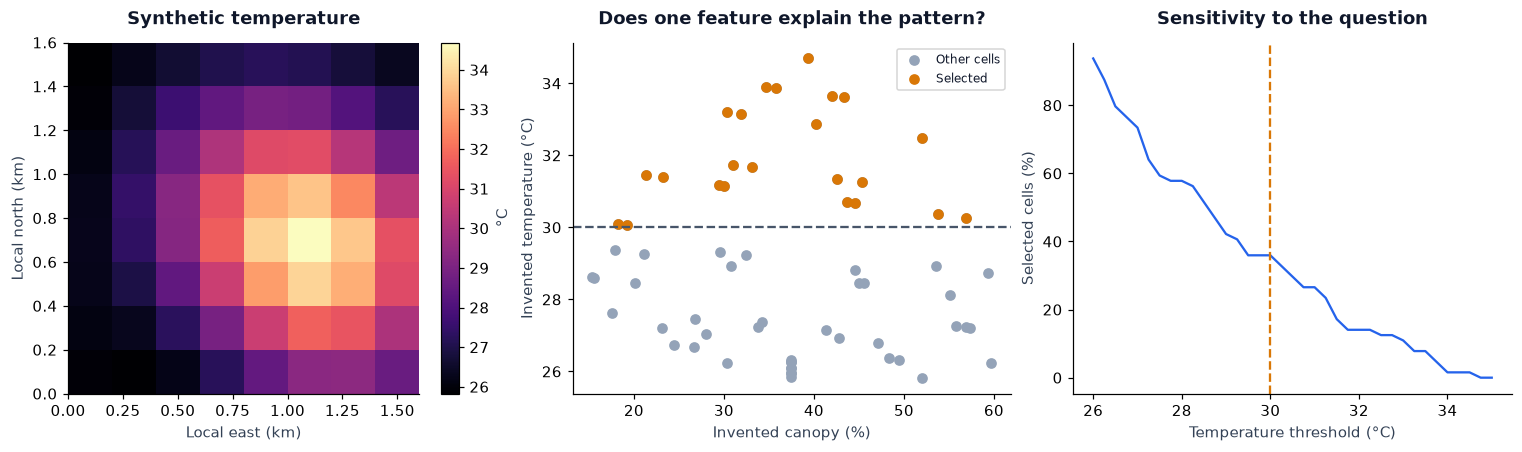

In [3]:
from astra_lab import PLAN_SCHEMA, apply_plan
plan = {"field": "temperature_c", "operator": ">=", "threshold": 30.0,
        "reason": "Find cells that meet the explicit 30 C teaching threshold."}
selected = apply_plan(table, plan)
selection_ids = set(selected.id)
print(f"Selected {len(selected)} of {len(table)} cells")
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
heat = table.temperature_c.to_numpy().reshape(8, 8)
im = axes[0].imshow(heat, origin="lower", cmap="magma", extent=(0,1.6,0,1.6))
axes[0].set(xlabel="Local east (km)", ylabel="Local north (km)", title="Synthetic temperature")
fig.colorbar(im, ax=axes[0], label="°C")
axes[1].scatter(table.canopy_pct, table.temperature_c, c="#94a3b8", label="Other cells")
axes[1].scatter(selected.canopy_pct, selected.temperature_c, c="#d97706", label="Selected")
axes[1].axhline(plan['threshold'], color="#475569", ls="--")
axes[1].set(xlabel="Invented canopy (%)", ylabel="Invented temperature (°C)", title="Does one feature explain the pattern?")
axes[1].legend(fontsize=8)
thresholds = np.linspace(26,35,37)
shares = [100 * table.temperature_c.ge(t).mean() for t in thresholds]
axes[2].plot(thresholds, shares)
axes[2].axvline(30, color="#d97706", ls="--")
axes[2].set(xlabel="Temperature threshold (°C)", ylabel="Selected cells (%)", title="Sensitivity to the question")
plt.show()

In [4]:
city_map = Map(center=(-122.291,37.907), zoom=13, height="550px")
city_map.add_choropleth(city, "temperature_c", name="Synthetic temperature (°C)", colormap="magma")
selected_fc = {"type":"FeatureCollection", "features":[f for f in city['features'] if f['properties']['id'] in selection_ids]}
if selected_fc['features']:
    city_map.add_geojson(selected_fc, name="Selected: at least 30 °C", fillOpacity=.05,
                        strokeColor="#22d3ee", strokeWidth=3)
display(city_map)
save_json("exports/selected_cells.geojson", selected_fc)
save_json("exports/teaching_city.geolibre.json", city_map.to_project())

'exports\\teaching_city.geolibre.json'

### Change the threshold and watch both views

Move the slider, release it, and compare the selected cells with the distribution. The orange cells on the map and the count in the chart use the same rule. This control explores sensitivity; the Astra request below still asks the explicit 30 °C question.

In [5]:
import copy
import ipywidgets as widgets
linked_map = Map(center=(-122.291,37.907),zoom=13,height="450px")
linked_map.add_geojson(city,name="All synthetic cells",fillColor="#cbd5e1",fillOpacity=.25,strokeWidth=.5)
base_project = copy.deepcopy(linked_map.project)
slider = widgets.FloatSlider(value=30,min=26,max=35,step=.25,description="Threshold °C",
                             continuous_update=False,style={"description_width":"initial"})
def update_threshold(threshold):
    picked = apply_plan(table,{**plan,"threshold":threshold})
    ids = set(picked.id)
    linked_map.project = copy.deepcopy(base_project)
    if ids:
        linked_map.add_geojson({"type":"FeatureCollection","features":[f for f in city['features'] if f['properties']['id'] in ids]},
                              name=f"At least {threshold:g} °C",fillColor="#d97706",fillOpacity=.85,strokeWidth=.7)
    fig,ax=plt.subplots(figsize=(9,3),layout="constrained")
    ax.hist(table.temperature_c,bins=np.arange(25,36,.5),color="#94a3b8")
    ax.axvline(threshold,color="#d97706",lw=3)
    ax.set(xlabel="Synthetic temperature (°C)",ylabel="Cells",
           title=f"{len(picked)} / {len(table)} cells meet the threshold")
    plt.show()
linked_chart = widgets.interactive_output(update_threshold,{"threshold":slider})
display(widgets.VBox([slider,linked_chart]),linked_map)

## 3. Prepare a real Astra structured-output request

Astra receives the question, units, a compact table and the allowed plan schema. Geography is already attached to stable cell IDs. Change the question to “canopy at most 25%” to try a different valid plan; after importing a response, recompute the selected map with the same function.

In [6]:
evidence = {"evidence_id":"synthetic_city", "crs":"EPSG:4326 for display; local grid in metres",
            "cell_size_m":200, "source":"synthetic teaching fixture", "rows":table.to_dict('records')}
request = make_request("Select cells with temperature at least 30 degrees C. Return a bounded plan.",
                       evidence, schema=PLAN_SCHEMA)
save_json("exports/spatial_plan_request.json", request)
print("Prepared", request['model'], "request; no API call made.")

Prepared gpt-6-astra request; no API call made.


## Optional: run this request with GPT-6 Astra

All calculations above run locally. The exported request has **not been sent** and any example plan is **hand-authored**, not a recorded model response. To obtain a live response:

1. Download the generated request from JupyterLite's file browser (right-click → Download).
2. In a full CPython terminal in this repository, set `OPENAI_API_KEY` in that terminal's environment. Never put the key in a notebook, output, or the static site.
3. Preview with `python scripts/run_astra.py PATH_TO_REQUEST.json`. Send deliberately with `--send --output astra_response.json`. This uses your API account and can incur charges.
4. Upload `astra_response.json` to the notebook folder, set the import path in the next cell, and rerun it. Inspect its evidence claims before using them.

For notebook 15, also download `accessibility_evidence.json` and pass `--evidence PATH_TO_EVIDENCE.json`. The runner only dispatches the one allowlisted local tool, with a bounded number of rounds.

The static JupyterLite site does not host this runner or proxy requests. Model access depends on your API project. Image reading is an aid to interpretation; geometry, distances and metrics come from code and explicit metadata.

In [7]:
RESPONSE_PATH = None  # e.g. "astra_response.json" after uploading an actual response
if RESPONSE_PATH:
    actual_plan = json.loads(response_text(json.loads(Path(RESPONSE_PATH).read_text())))
    actual_selection = apply_plan(table, actual_plan)
    display(actual_selection)
    actual_fc = {"type":"FeatureCollection", "features":[f for f in city['features'] if f['properties']['id'] in set(actual_selection.id)]}
    if actual_fc['features']:
        actual_map = Map(center=(-122.291,37.907),zoom=13,height="450px")
        actual_map.add_geojson(actual_fc,name="Validated Astra selection",fillColor="#0f766e")
        display(actual_map)
    else:
        print("The validated plan selected no cells.")
    print("Matches hand-authored baseline IDs:", set(actual_selection.id) == selection_ids)
else:
    print("Offline teaching run. No Astra response imported.")

Offline teaching run. No Astra response imported.


## 4. Transfer the pattern to real GeoAI

Use lab 02's county features or lab 08's STAC footprints in place of the synthetic grid. Retain units, source IDs, date and geometry. Let Astra propose a bounded operation; let Python perform it; compare the result with a baseline and inspect it in GeoLibre.

**Explain:** why can a perfectly valid JSON plan still misunderstand a question? Try a threshold beyond the physical range and verify that validation rejects it. Then change a valid threshold and describe the selection curve without implying that cell share equals population share.

## Data & software citations

- Teaching fixtures: deterministic synthetic arrays and networks authored in this repository. Values, scenes, facilities and outcomes are invented; coordinates only anchor the display. No actual people, environmental measurements, or service areas are represented.
- [GeoLibre](https://geolibre.app/) and [GeoLibre map controls](https://geolibre.app/user-guide/map-controls/); `geolibre==3.0.0` project builders through `geolibre_lite.LiteMap`.
- [GeoAI](https://opengeoai.org/): full Python/GPU continuation for imagery models. These browser labs implement workflow patterns; they do not install or run `geoai-py`.
- [GPT-6 Astra model](https://developers.openai.com/api/docs/models/gpt-6-astra), [Structured Outputs](https://developers.openai.com/api/docs/guides/structured-outputs), [image inputs](https://developers.openai.com/api/docs/guides/images-vision), and [function calling](https://developers.openai.com/api/docs/guides/function-calling). API examples checked 2026-10-02.
- [Pyodide packages](https://pyodide.org/en/stable/usage/packages-in-pyodide.html), [Matplotlib](https://matplotlib.org/stable/), [Plotly Python](https://plotly.com/python/).
- GeoLibre basemap tiles retain their provider attribution, including [OpenStreetMap contributors](https://www.openstreetmap.org/copyright) where applicable.

See `DATA_SOURCES.md` for the source register and runtime boundaries.